# Word2Vec Results Demo

This notebook is for **showing the learned embeddings only**.  
It does **not** include training. It focuses on:

- nearest neighbors
- word analogy
- similarity sanity checks
- PCA
- t-SNE
- cosine similarity heatmap

You can choose where to load `W_center.npy` from in the configuration cell below.


In [258]:
from pathlib import Path
PROJECT_ROOT = Path(".").resolve()
# Option A: point to a run directory, then let the notebook resolve checkpoint paths
RUN_DIR = PROJECT_ROOT / "checkpoints" / "183537_con"
CHECKPOINT_SUBDIR = "final"   # "final" or "latest"

# Option B: directly point to checkpoint files (overrides RUN_DIR if not None)
W_CENTER_PATH = None
W_CONTEXT_PATH = None

# Which embedding should be used for analysis?
# Options: "center", "context", "average"
EMBEDDING_SOURCE = "average"

In [259]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

try:
    import sklearn  # noqa: F401
except Exception as e:
    raise ImportError("This notebook needs scikit-learn. Install it with: pip install scikit-learn") from e

# =========================
# Configuration
# =========================

# How to load vocab?
# Options: "rebuild", "json", "npy", "pkl", "none"
VOCAB_MODE = "json"
VOCAB_PATH = RUN_DIR / "vocab.json"

# If VOCAB_MODE == "rebuild", whether to reuse settings from run_config.json
USE_RUN_CONFIG_FOR_VOCAB = True

# Demo settings
TOP_K = 10
PCA_WORDS = [
    "king", "queen", "prince", "princess",
    "man", "woman", "boy", "girl",
    "paris", "france", "berlin", "germany",
    "london", "england", "rome", "italy",
    "cat", "dog", "horse", "bird",
    "car", "train", "plane", "city",
    "music", "science", "art", "history",
]
TSNE_MAX_WORDS = 250
TSNE_RANDOM_STATE = 42

SHOW_LOSS_CURVE = True

print(f"PROJECT_ROOT = {PROJECT_ROOT}")

PROJECT_ROOT = C:\Users\User1\OneDrive - TU Eindhoven\Job\JetBrains\Hallucination Detection


In [ ]:
# Load helper utilities from the companion file next to this notebook.
# Keeping them outside the main demo flow makes the notebook easier to present.

NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from src.eval.demo_helpers import (
    resolve_checkpoint_paths,
    load_run_config,
    load_numpy_embeddings,
    l2_normalize_rows,
    maybe_load_vocab,
    nearest_neighbors,
    analogy,
    similarity_table,
    plot_loss_if_available,
    collect_existing_words,
    plot_pca,
    plot_tsne,
    plot_similarity_heatmap,
    maybe_pick_default_words,
)

Load embeddings and vocab

In [261]:
# =========================
# Load embeddings and vocab
# =========================

W_CENTER_PATH_RESOLVED, W_CONTEXT_PATH_RESOLVED = resolve_checkpoint_paths(
    run_dir=RUN_DIR,
    checkpoint_subdir=CHECKPOINT_SUBDIR,
    w_center_path=W_CENTER_PATH,
    w_context_path=W_CONTEXT_PATH,
)

if not W_CENTER_PATH_RESOLVED.exists():
    raise FileNotFoundError(
        f"Cannot find W_center.npy at: {W_CENTER_PATH_RESOLVED}\n"
        "Please update RUN_DIR or W_CENTER_PATH in the configuration cell."
    )

run_config = load_run_config(RUN_DIR)
W_center, W_context, EMB = load_numpy_embeddings(
    W_CENTER_PATH_RESOLVED,
    W_CONTEXT_PATH_RESOLVED,
    embedding_source=EMBEDDING_SOURCE,
)
EMB_NORM = l2_normalize_rows(EMB)

word2id, id2word = maybe_load_vocab(
    vocab_mode=VOCAB_MODE,
    vocab_path=VOCAB_PATH,
    project_root=PROJECT_ROOT,
    run_config=run_config,
    use_run_config_for_vocab=USE_RUN_CONFIG_FOR_VOCAB,
)

print("Loaded embedding matrices:")
print(f"  W_center: {W_center.shape}")
print(f"  W_context: {None if W_context is None else W_context.shape}")
print(f"  Embedding source: {EMBEDDING_SOURCE}")
print(f"  Final embedding matrix: {EMB.shape}")
print()
print("Loaded vocab:")
print(f"  vocab size = {None if word2id is None else len(word2id)}")

if run_config is not None:
    print()
    print("run_config preview:")
    for k in [
        "embedding_dim",
        "max_vocab_size",
        "min_freq",
        "window_size",
        "num_negative_samples",
        "learning_rate",
        "split",
    ]:
        if k in run_config:
            print(f"  {k}: {run_config[k]}")

FileNotFoundError: Cannot find W_center.npy at: C:\Users\User1\OneDrive - TU Eindhoven\Job\JetBrains\Hallucination Detection\checkpoints\183537_con\final\W_center.npy
Please update RUN_DIR or W_CENTER_PATH in the configuration cell.

## Optional: training loss

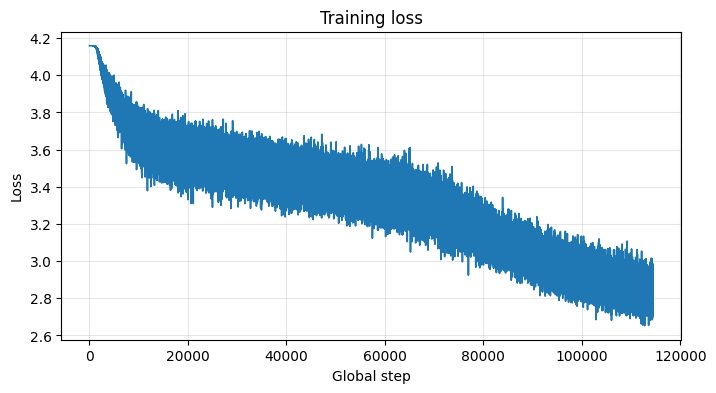

In [ ]:
if SHOW_LOSS_CURVE:
    loss_df = plot_loss_if_available(RUN_DIR)
else:
    loss_df = None

## Nearest neighbors

This is the simplest qualitative check:  
for a query word, list the top cosine-nearest words in the learned embedding space.


In [ ]:
query_words = [
    "king", "queen", "man", "woman",
    "paris", "france", "berlin", "germany",
    "cat", "dog", "music", "science",
]

available_queries = [w for w in query_words if word2id is not None and w in word2id]
if not available_queries:
    print("None of the default query words are in the vocab. Replace query_words with words from your corpus.")
else:
    for q in available_queries:
        print(f"\n[{q}]")
        for neighbor, score in nearest_neighbors(
            q, EMB, word2id, id2word, top_k=TOP_K, normalized_embeddings=EMB_NORM
        ):
            print(f"  {neighbor:<18} {score: .4f}")


[king]
  company             0.9111
  any                 0.9072
  small               0.9035
  <UNK>               0.8843
  ii                  0.8770
  wrote               0.8722
  those               0.8696
  black               0.8605
  based               0.8547
  often               0.8541

[queen]
  specimens           0.9698
  looked              0.9674
  studied             0.9673
  wooden              0.9664
  attributed          0.9663
  ed                  0.9661
  bones               0.9659
  k.                  0.9655
  mac                 0.9654
  y                   0.9651

[man]
  who                 0.8778
  where               0.8701
  both                0.8696
  there               0.8686
  about               0.8648
  been                0.8644
  made                0.8625
  ;                   0.8609
  some                0.8597
  film                0.8585

[woman]
  tourism             0.7886
  limitations         0.7758
  rugby               0.7727
  sided   

## Word analogy

Classic analogy query:

\[
b - a + c \approx ?
\]

Example: `man : king :: woman : queen`


In [ ]:
analogy_examples = [
    ("man", "king", "woman"),
    ("paris", "france", "berlin"),
    ("boy", "prince", "girl"),
]

for a, b, c in analogy_examples:
    if word2id is None or any(w not in word2id for w in (a, b, c)):
        print(f"Skip analogy ({a}, {b}, {c}) because at least one word is missing from the vocab.")
        continue

    print(f"\n{a} : {b} :: {c} : ?")
    for word, score in analogy(
        a, b, c, EMB, word2id, id2word, top_k=TOP_K, normalized_embeddings=EMB_NORM
    ):
        print(f"  {word:<18} {score: .4f}")


man : king :: woman : ?
  battlefield         0.8967
  intelligence        0.8826
  maximum             0.8820
  lowest              0.8814
  heritage            0.8793
  replied             0.8764
  pryce               0.8763
  delay               0.8738
  delayed             0.8726
  rangers             0.8724

paris : france :: berlin : ?
  utilized            0.6554
  hatch               0.6425
  touchdown           0.6392
  freely              0.6391
  reverse             0.6388
  orbits              0.6374
  competitions        0.6332
  timed               0.6324
  tensions            0.6322
  bowlers             0.6319

boy : prince :: girl : ?
  training            0.8861
  faith               0.8785
  priest              0.8758
  language            0.8749
  st.                 0.8745
  henry               0.8742
  ali                 0.8734
  han                 0.8718
  flying              0.8703
  greek               0.8703


## Similarity sanity checks

A few hand-picked word pairs can be useful as a quick semantic sanity check.


In [ ]:
sanity_pairs = [
    ("cat", "dog"),
    ("car", "train"),
    ("paris", "france"),
    ("king", "queen"),
    ("cat", "democracy"),
    ("music", "science"),
]

sim_df = similarity_table(sanity_pairs, EMB, word2id)
sim_df.sort_values("cosine_similarity", ascending=False)

,word_1,word_2,cosine_similarity
0,cat,dog,0.963245
1,car,train,0.927207
3,king,queen,0.491383
2,paris,france,0.310898
4,cat,democracy,0.079559
5,music,science,-0.433768


## PCA visualization

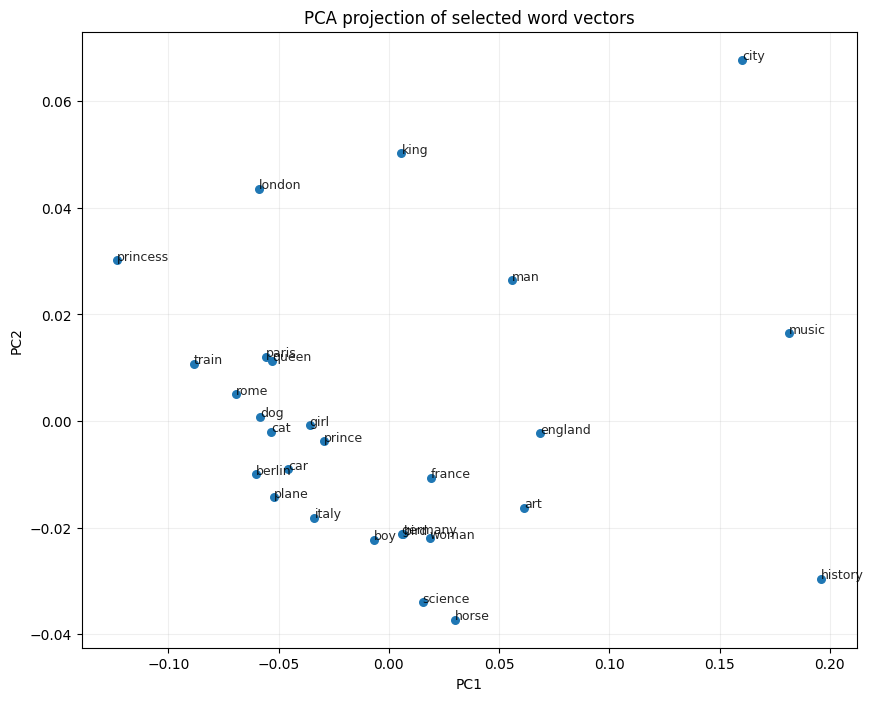

In [ ]:
plot_pca(PCA_WORDS, EMB, word2id)

## t-SNE visualization

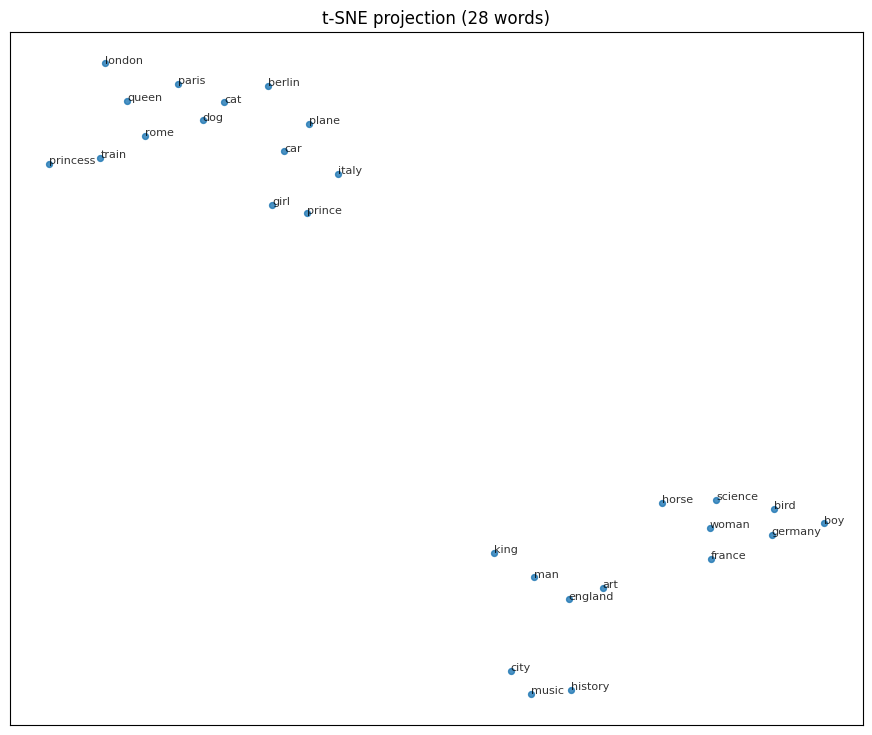

In [ ]:
if word2id is None:
    raise ValueError("Need vocab for t-SNE visualization")

candidate_words = collect_existing_words(PCA_WORDS, word2id)
if len(candidate_words) < 20:
    candidate_words = maybe_pick_default_words(id2word, limit=TSNE_MAX_WORDS)

plot_tsne(
    candidate_words,
    EMB,
    word2id,
    max_words=TSNE_MAX_WORDS,
    random_state=TSNE_RANDOM_STATE,
)

## Cosine similarity heatmap

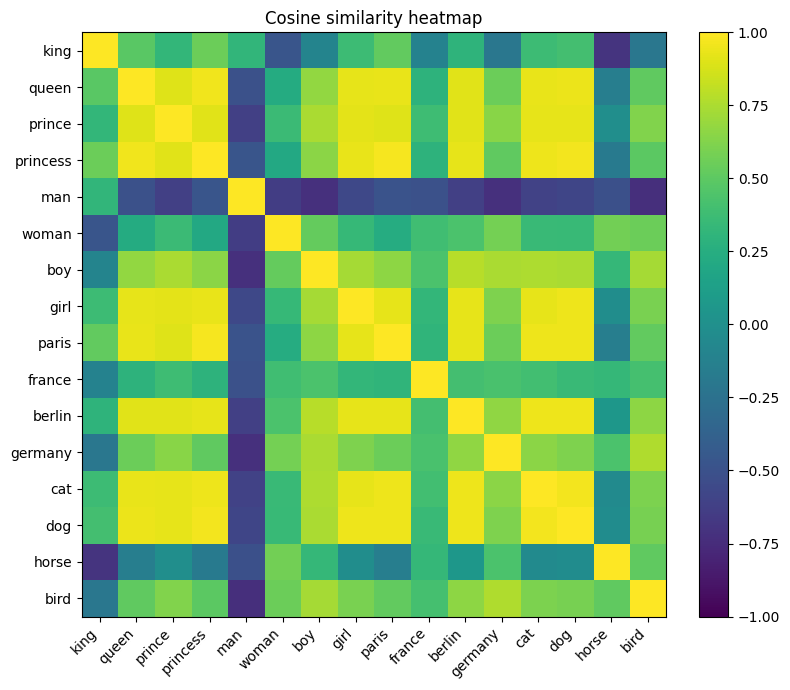

In [ ]:
heatmap_words = [
    "king", "queen", "prince", "princess",
    "man", "woman", "boy", "girl",
    "paris", "france", "berlin", "germany",
    "cat", "dog", "horse", "bird",
]
plot_similarity_heatmap(heatmap_words, EMB, word2id)

## Custom queries

Nearest neighbors for: king



,neighbor,cosine_similarity
0,company,0.911084
1,any,0.907219
2,small,0.903544
3,<UNK>,0.884318
4,ii,0.877014
5,wrote,0.872249
6,those,0.869564
7,black,0.860480
8,based,0.854682
9,often,0.854108



Analogy:


,candidate,score
0,battlefield,0.896713
1,intelligence,0.882643
2,maximum,0.881956
3,lowest,0.881428
4,heritage,0.879269
5,replied,0.876406
6,pryce,0.876335
7,delay,0.873776
8,delayed,0.872561
9,rangers,0.872408



Heatmap:


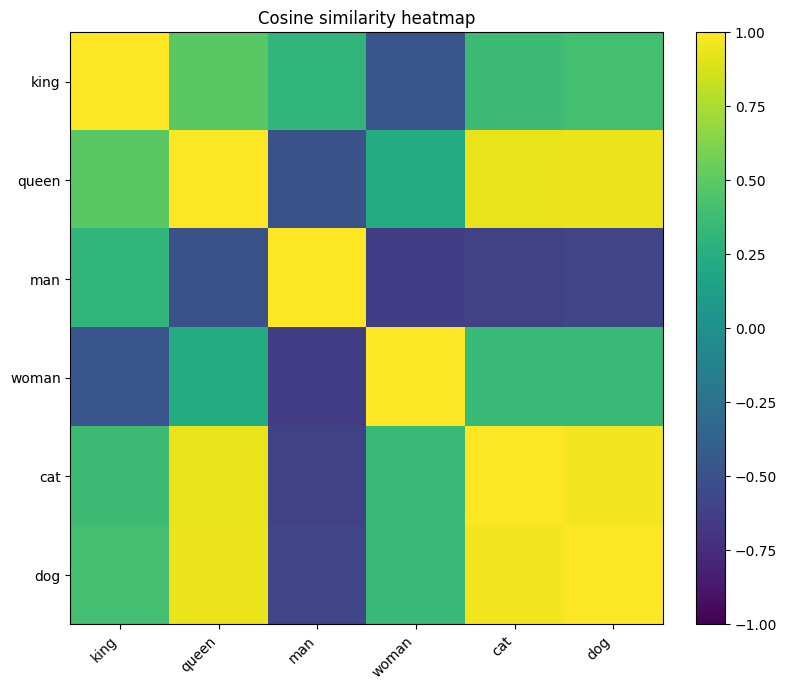

In [ ]:
my_query = "king"
my_analogy = ("man", "king", "woman")
my_heatmap_words = ["king", "queen", "man", "woman", "cat", "dog"]

if word2id is not None and my_query in word2id:
    print(f"Nearest neighbors for: {my_query}\n")
    display(pd.DataFrame(
        nearest_neighbors(
            my_query,
            EMB,
            word2id,
            id2word,
            top_k=TOP_K,
            normalized_embeddings=EMB_NORM,
        ),
        columns=["neighbor", "cosine_similarity"],
    ))
else:
    print(f"Word not found: {my_query}")

print("\nAnalogy:")
try:
    display(pd.DataFrame(
        analogy(
            *my_analogy,
            embeddings=EMB,
            word2id=word2id,
            id2word=id2word,
            top_k=TOP_K,
            normalized_embeddings=EMB_NORM,
        ),
        columns=["candidate", "score"],
    ))
except Exception as e:
    print(f"Analogy failed: {e}")

print("\nHeatmap:")
try:
    plot_similarity_heatmap(my_heatmap_words, EMB, word2id)
except Exception as e:
    print(f"Heatmap failed: {e}")

## Presentation tips

A clean way to present this notebook:

1. Show the configuration and confirm which checkpoint you loaded.
2. Show nearest neighbors for a few intuitive query words.
3. Show one or two analogy examples.
4. Show the PCA plot.
5. Use the heatmap to explain local semantic structure.
6. Mention limitations:
   - quality depends on corpus size and preprocessing
   - rare words are often noisy
   - analogy results are not always stable


## Appendix: helper utilities

To keep the demo notebook clean, helper functions are stored in a companion file in `src/` foler:

`demo_helpers.py`

The next cell shows where that file is loaded from.


In [ ]:
from pathlib import Path
HELPER_FILE = Path("src/eval/demo_helpers.py").resolve()
print(HELPER_FILE)

C:\Users\User1\OneDrive - TU Eindhoven\Job\JetBrains\Hallucination Detection\src\demo_helpers.py
